In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df=pd.read_csv('Telco churn.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#conversion of type from dataset
df['TotalCharges']=pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'# erors='coerce' converts errorr into Nan values
    ) 
df['SeniorCitizen']=df['SeniorCitizen'].map({
    1:'Yes',
    0:'No'
})

In [5]:
df.drop('customerID',axis=1,inplace=True)

In [6]:
print(df.size)
print(df.shape)


140860
(7043, 20)


In [7]:
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
df.dropna(subset='TotalCharges',axis=0,inplace=True)

In [9]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

### EDA

In [10]:
numeric=df.select_dtypes(include='number')
categoried=df.select_dtypes(include='object')
print(numeric.columns)
print(categoried.columns)

Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [11]:
for i in numeric:
    print(df[i].nunique())
    print(df[i].unique())
    

72
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
1584
[29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
6530
[  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]


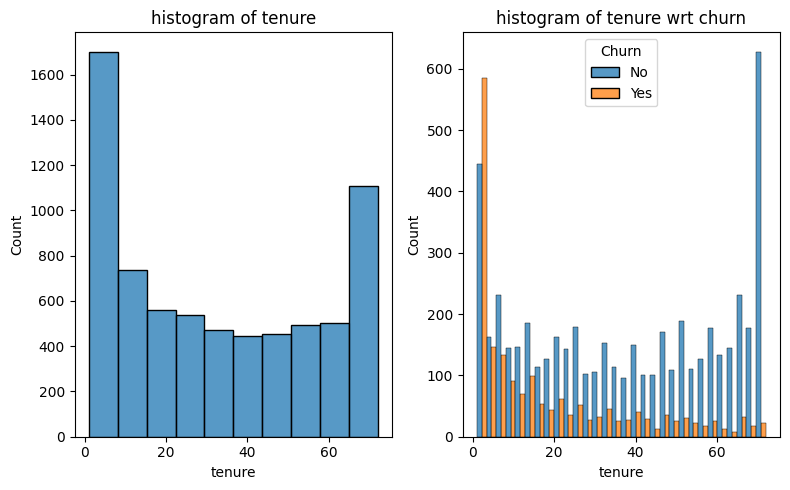

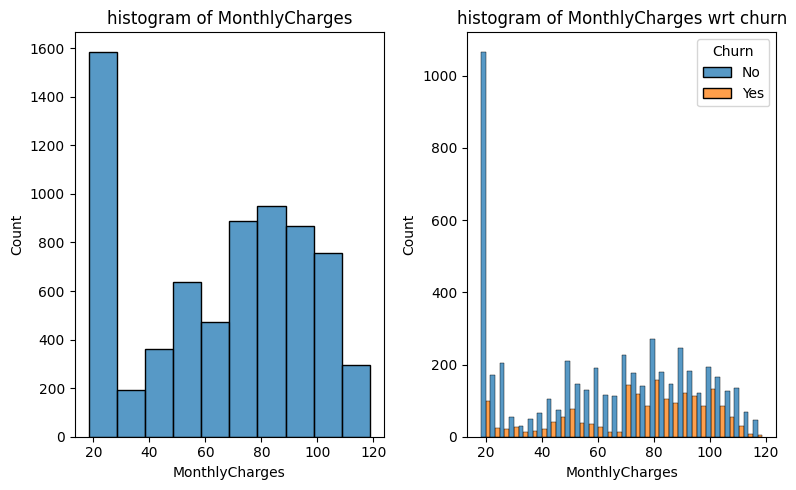

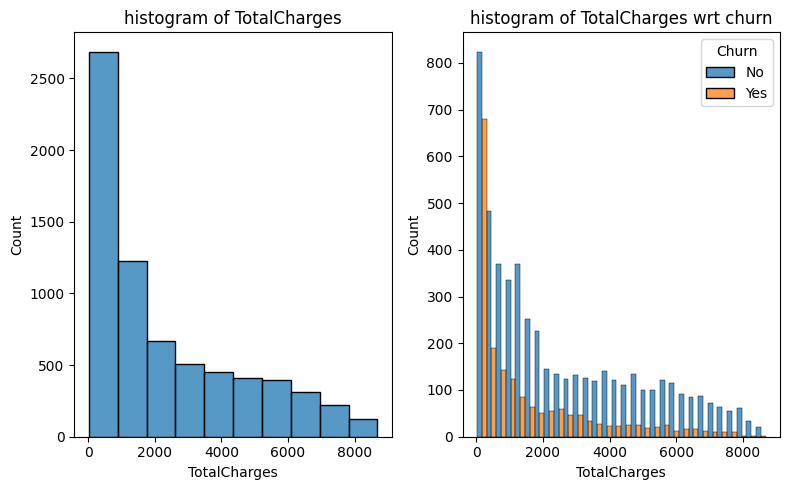

In [12]:
for variable in numeric:
    plt.figure(figsize=(8,5))
    plt.subplot(1,2,1)
    sns.histplot(data=df,x=variable,bins=10)
    plt.title(f"histogram of {variable}")
    
    plt.subplot(1,2,2)
    sns.histplot(data=df,x=variable,hue='Churn',bins=30,multiple='dodge')
    plt.title(f"histogram of {variable} wrt churn")
    plt.tight_layout()

In [13]:
for var in categoried:
    print(f"the no of unique varable in {var} is ",df[var].nunique())

the no of unique varable in gender is  2
the no of unique varable in SeniorCitizen is  2
the no of unique varable in Partner is  2
the no of unique varable in Dependents is  2
the no of unique varable in PhoneService is  2
the no of unique varable in MultipleLines is  3
the no of unique varable in InternetService is  3
the no of unique varable in OnlineSecurity is  3
the no of unique varable in OnlineBackup is  3
the no of unique varable in DeviceProtection is  3
the no of unique varable in TechSupport is  3
the no of unique varable in StreamingTV is  3
the no of unique varable in StreamingMovies is  3
the no of unique varable in Contract is  3
the no of unique varable in PaperlessBilling is  2
the no of unique varable in PaymentMethod is  4
the no of unique varable in Churn is  2


In [23]:
categoried.drop(columns=['Churn'],axis=1,inplace=True)

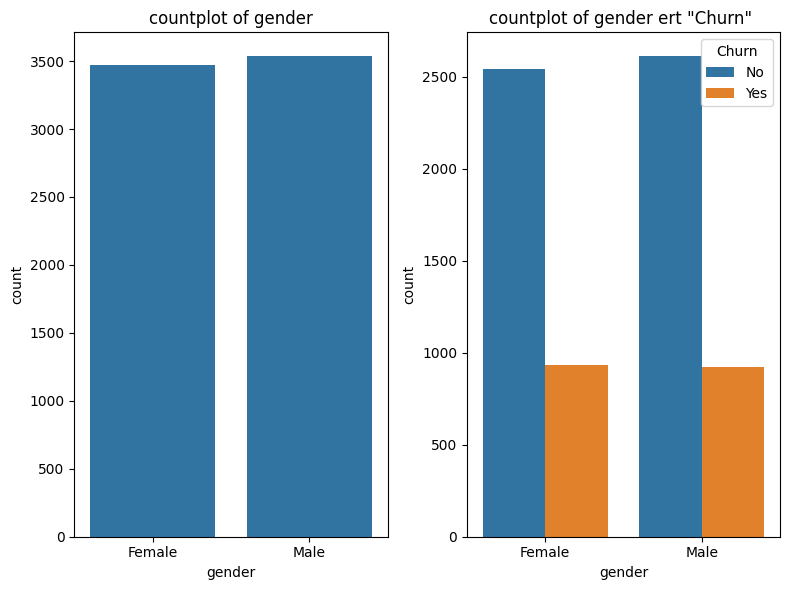

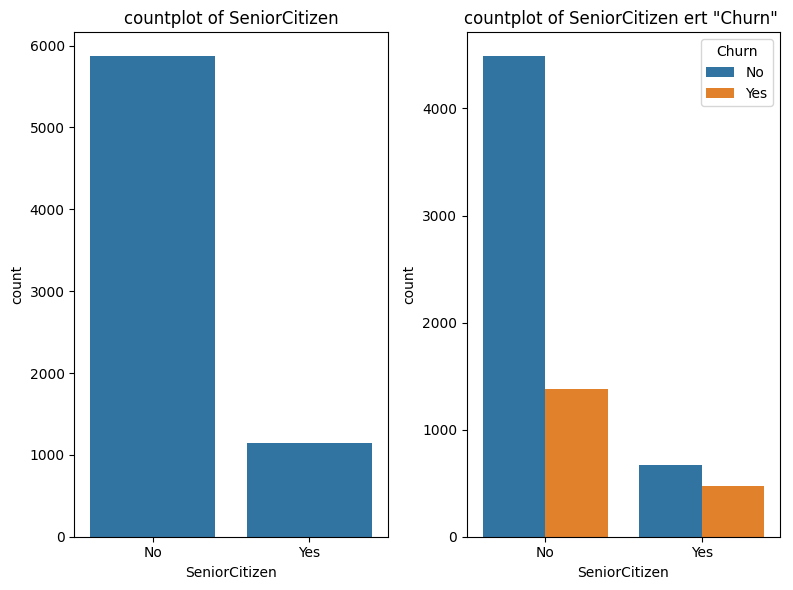

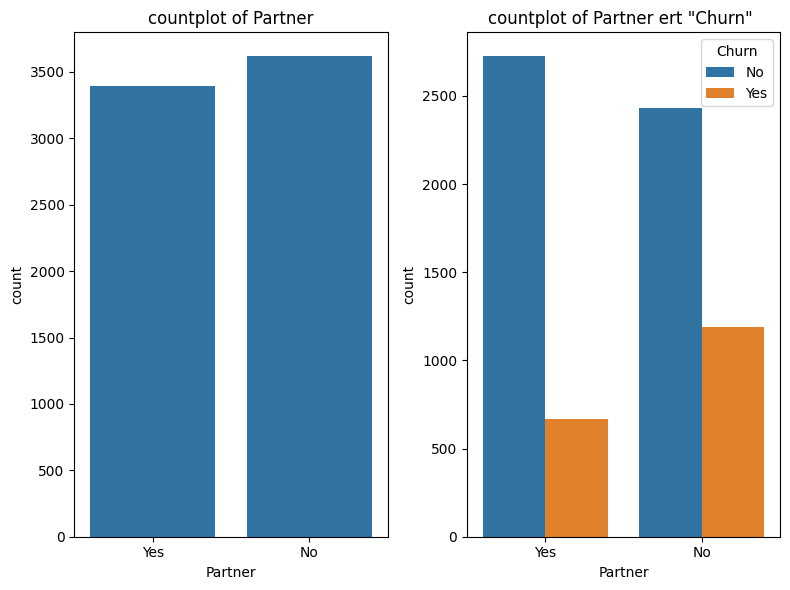

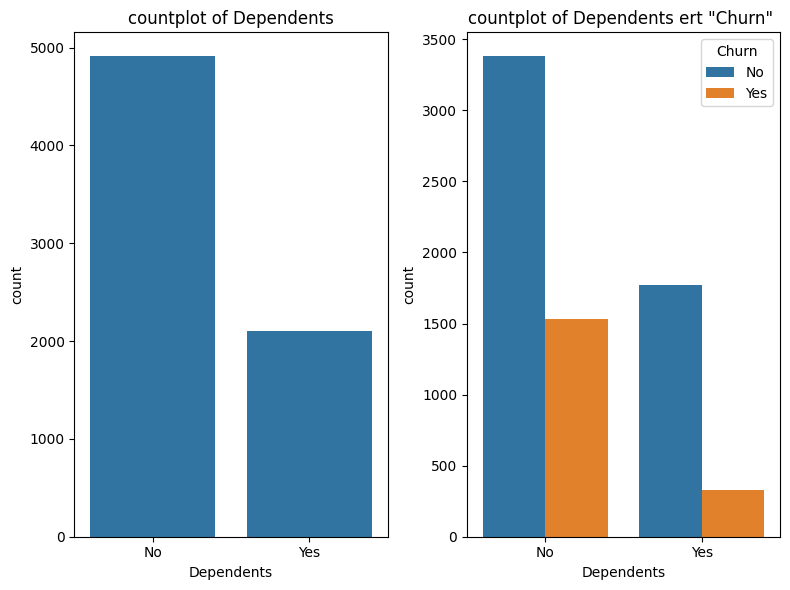

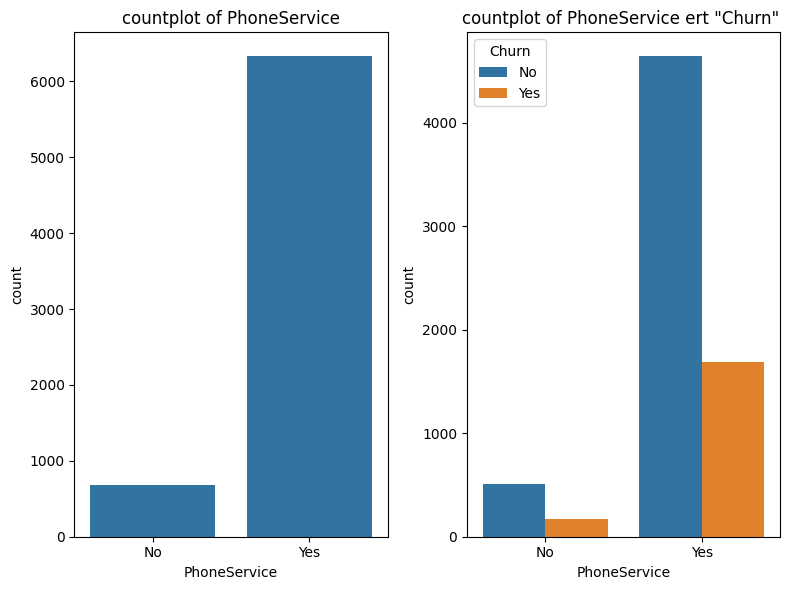

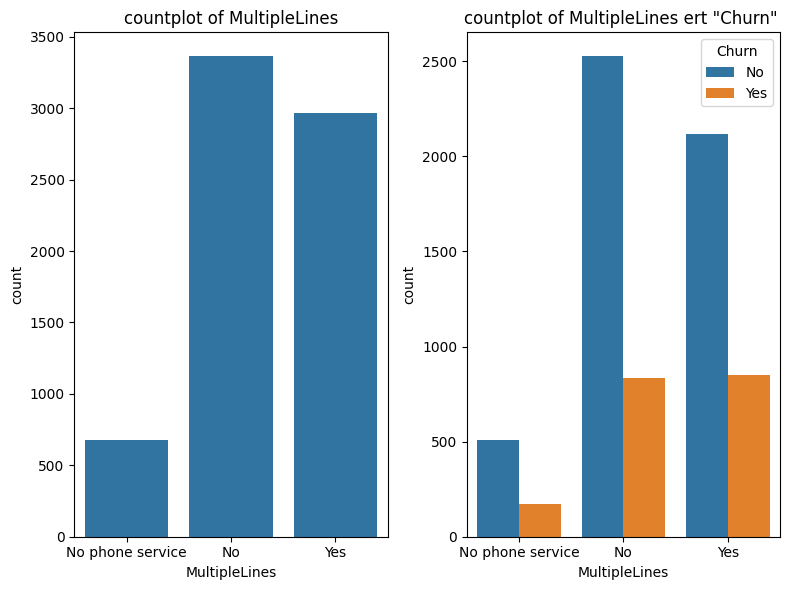

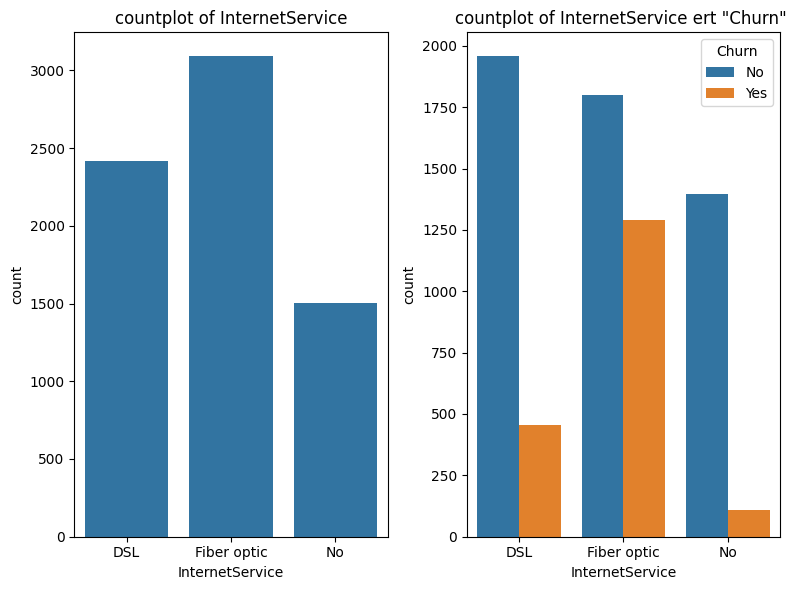

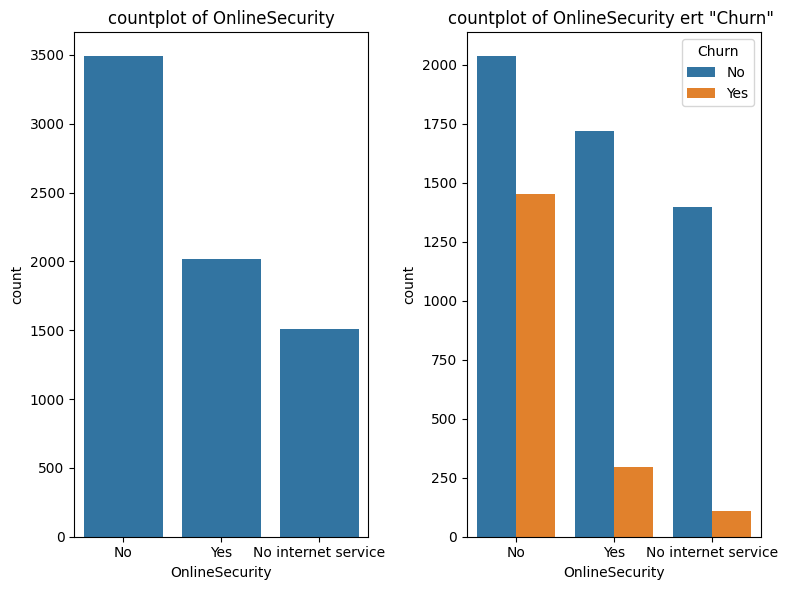

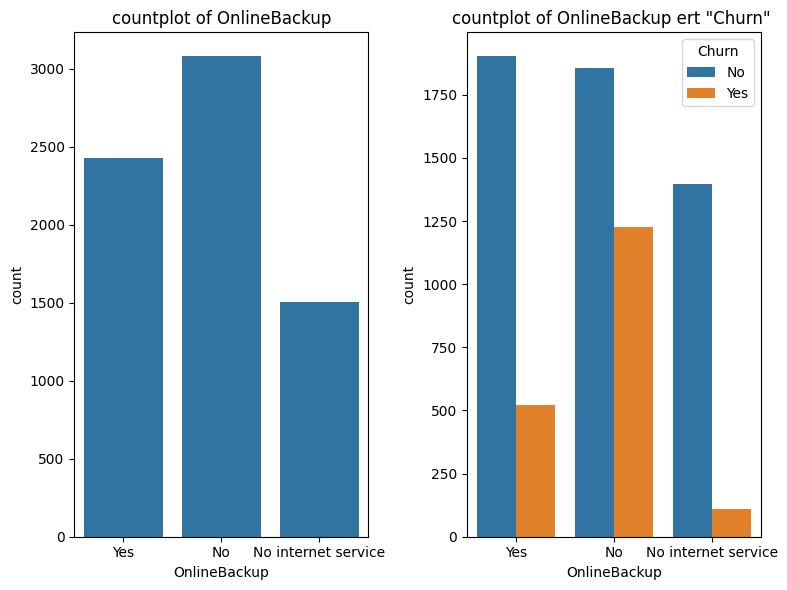

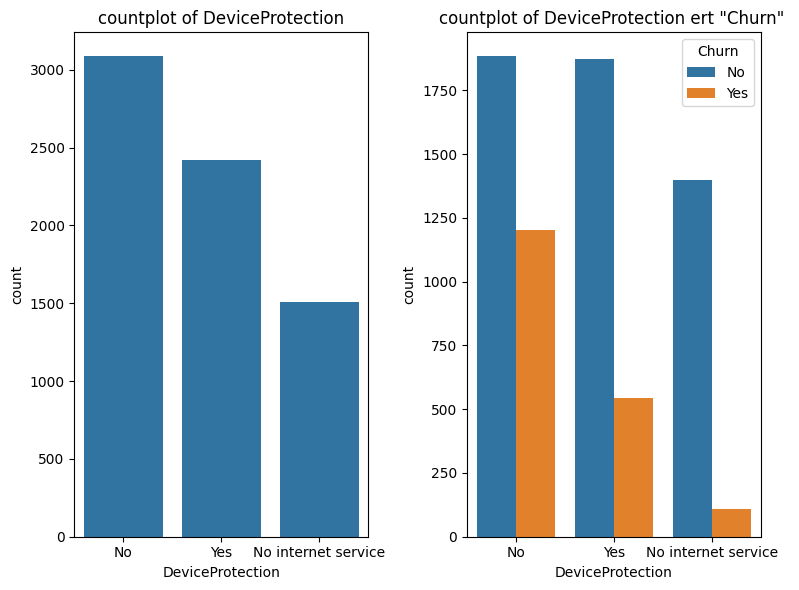

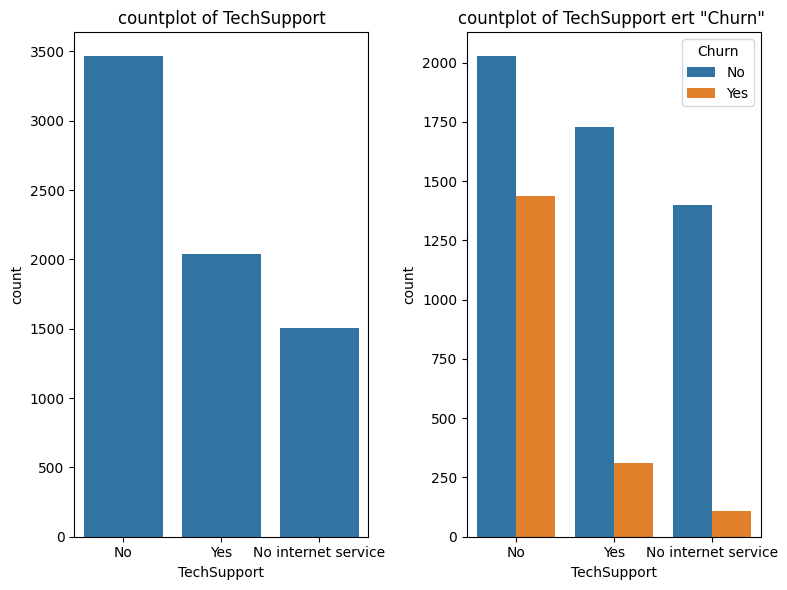

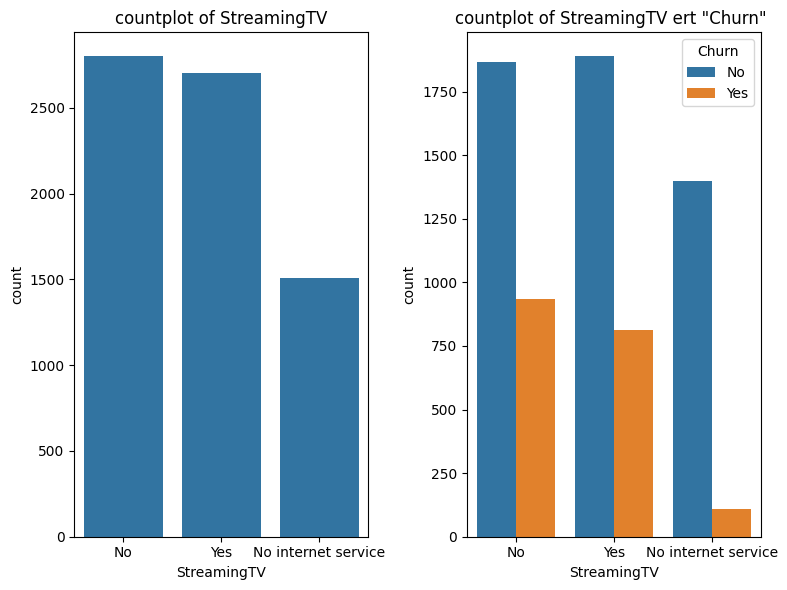

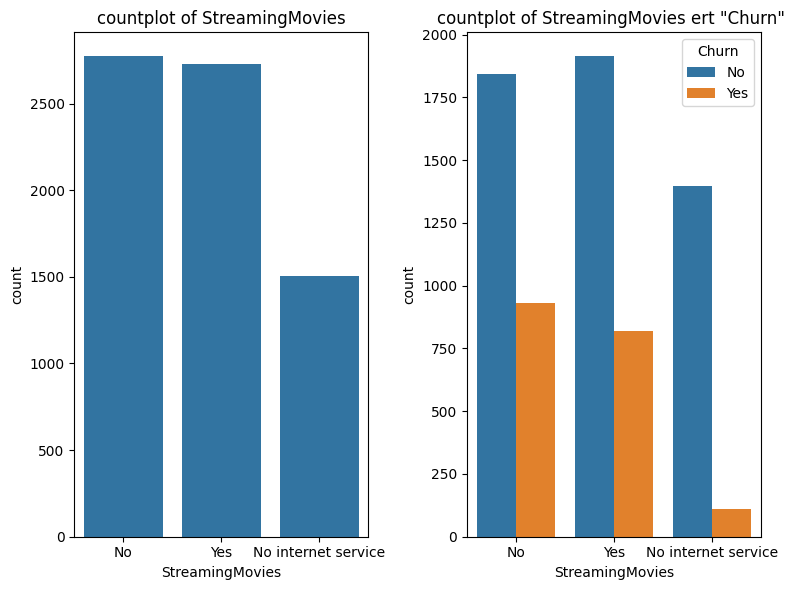

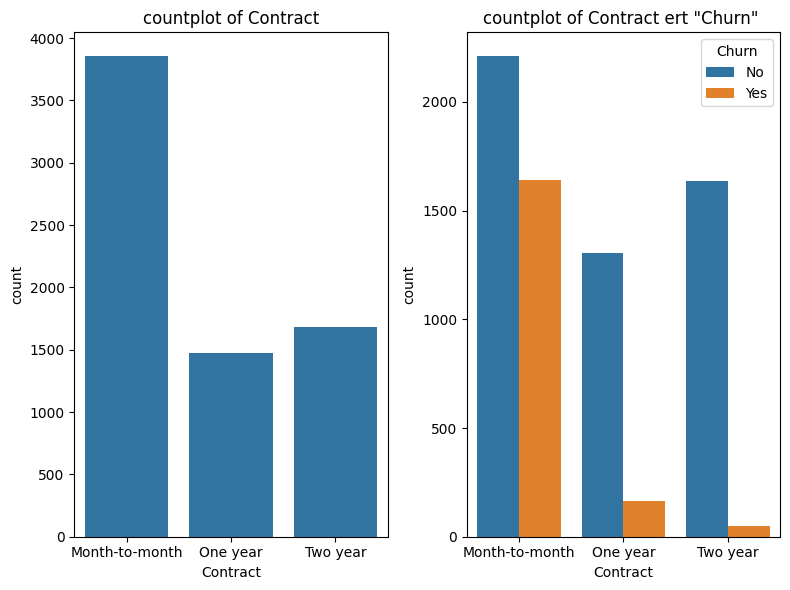

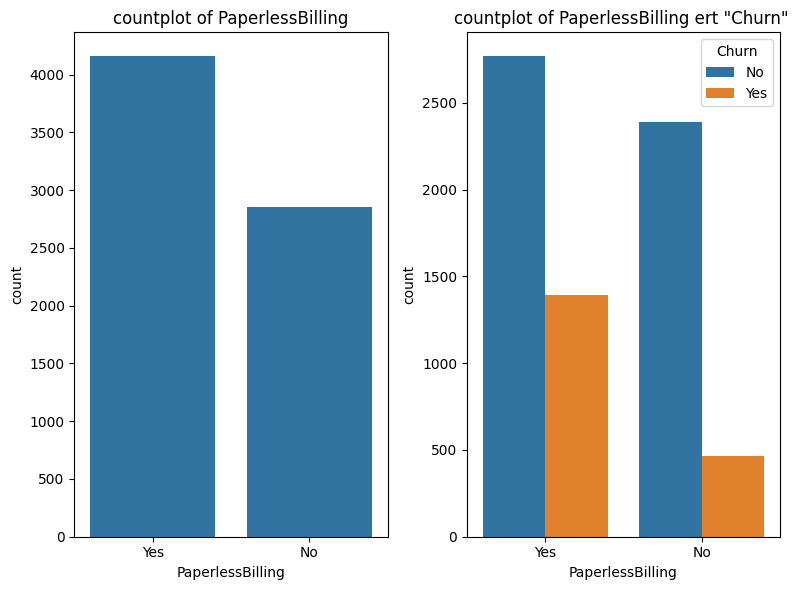

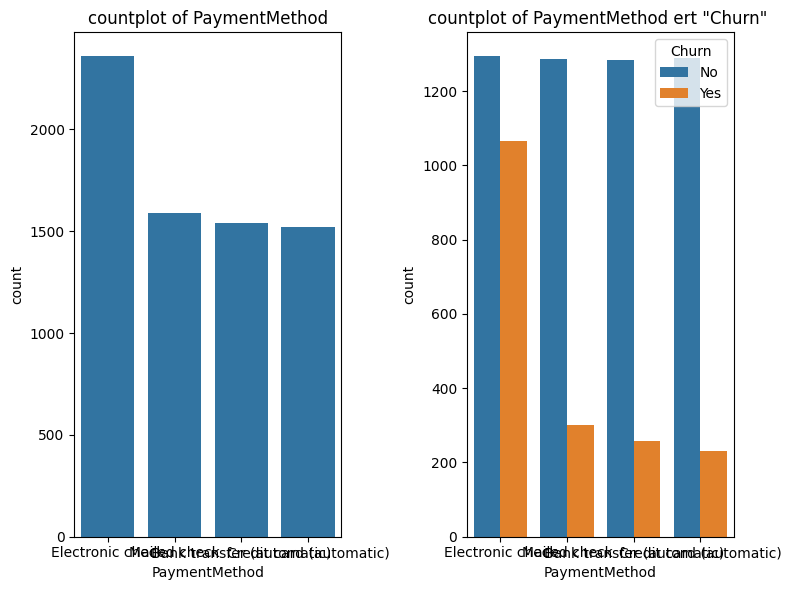

In [15]:
for variable in categoried:
    plt.figure(figsize=(8,6))
    plt.subplot(1,2,1)
    sns.countplot(data=df,x=variable)
    plt.title(f'countplot of {variable}')
    
    plt.subplot(1,2,2)
    sns.countplot(data=df,x=variable,hue=df['Churn'])
    plt.title(f'countplot of {variable} ert "Churn" ')

    plt.tight_layout()
    plt.show()
    

## Modl Building

### Two models 
1. logistic regression
2. random forest

In [68]:
from sklearn.pipeline import Pipeline

In [69]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [70]:
pipenum=Pipeline(
    steps=[
        ('impute',SimpleImputer(strategy='median'))
    ]
)

In [71]:
pipecat=Pipeline(
    steps=[
        ('impute',SimpleImputer(strategy='most_frequent')),
        ('encode',OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [72]:
from sklearn.compose import ColumnTransformer

In [73]:
transform=ColumnTransformer(
    transformers=[
        ('num',pipenum,numeric.columns.tolist()),
        ('cat',pipecat,categoried.columns.tolist())
    ]
)

### Logistic regression using three numeric variables

In [74]:
from sklearn.model_selection import train_test_split

In [75]:
y=df['Churn'].map({'Yes':1,"No":0})
x=df.drop(columns=['Churn'],axis=1)
print(y)
print(x)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7010, dtype: int64
      gender SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female            No     Yes         No       1           No   
1       Male            No      No         No      34          Yes   
2       Male            No      No         No       2          Yes   
3       Male            No      No         No      45           No   
4     Female            No      No         No       2          Yes   
...      ...           ...     ...        ...     ...          ...   
7038    Male            No     Yes        Yes      24          Yes   
7039  Female            No     Yes        Yes      72          Yes   
7040  Female            No     Yes        Yes      11           No   
7041    Male           Yes     Yes         No       4          Yes   
7042    Male            No      No         No      66          Yes   

         

In [76]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,random_state=10,test_size=0.2)

In [77]:
from sklearn.linear_model import LogisticRegression

In [78]:
pipeline=Pipeline(
    steps=[
        ('transform',transform),
        ('model',LogisticRegression(
            penalty='l2',
            C=1.0,
            random_state=10,
            max_iter=100,
            solver='lbfgs'
            
        ))
    ]
)

In [79]:
pipeline.fit(xtrain,ytrain)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(random_state=10))])

In [80]:
ypred=pipeline.predict(xtest)

In [93]:
from sklearn.metrics import (confusion_matrix,accuracy_score,precision_score,recall_score)

In [94]:

print("Recall:", confusion_matrix(ytest, ypred))
print("Accuracy:", accuracy_score(ytest, ypred))
print("Precision:", precision_score(ytest, ypred))
print("Recall:", recall_score(ytest, ypred))


Recall: [[912 118]
 [166 206]]
Accuracy: 0.797432239657632
Precision: 0.6358024691358025
Recall: 0.553763440860215


## random forest

In [86]:
from sklearn.ensemble import RandomForestClassifier

In [87]:
pipeline=Pipeline(
    steps=[
        ('transform',transform),
        ('model',RandomForestClassifier(
            n_estimators=200,
            random_state=10,
            min_samples_split=2,
            max_depth=10,
            max_features='sqrt'
        ))
    ]
)

In [88]:
pipeline.fit(xtrain,ytrain)

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        random_state=10))])

In [89]:
ypred=pipeline.predict(xtest)
print(type(ypred))
print(ypred[0:10])

<class 'numpy.ndarray'>
[0 1 0 0 1 0 0 0 0 0]


In [90]:
# ypred=np.where(ypred=='Yes',1,0)

In [91]:
print("Accuracy:", accuracy_score(ytest, ypred))
print("Precision:", precision_score(ytest, ypred))
print("Recall:", recall_score(ytest, ypred))

Accuracy: 0.797432239657632
Precision: 0.6358024691358025
Recall: 0.553763440860215


### Comparision